# Logistic Regression News Topic Classification
## Arseniy Uspenskiy
## USPARS001

Importing necessary modules and declaring constant values for the split folder names and feature extraction methods and a pytorch device

In [2]:
# general imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import itertools
import os
from typing import Optional

# pytorch
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# scikit learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

# constants
SPLITS = ("train", "dev", "test")
METHODS = ("bow", "tfidf")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Standalone function for loweercasing and stripping text data. Not used as part of the Loader class for easier use.

In [3]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

NewsDataLoader: holds all gathers all data for a single language. Locating and opening the directory and mapping both labels from labels.txt as well as producing a full-text from the headline and body of the individual split files.
Input:
- root, a string for the directory holding the language
- language, a string that is the name of the language folder

Methods:
- _load_labels for mapping the correct labels for that language
- _load_split for loading a single split
- load_splits iteratively calls _load_split on each split in the SPLITS list

Returns:
- A dictionary mapping each split name to it's processed data

In [4]:
class NewsDataLoader:

    def __init__(self, root, language):
        self.root = root
        self.language = language
        self.directory = os.path.join(root, language)
        self.labels = self._load_labels()
        self.label2id = {lab: i for i, lab in enumerate(self.labels)}

    def _load_labels(self):
        path = os.path.join(self.directory, "labels.txt")
        with open(path, encoding="utf-8") as f:
            return [line.strip() for line in f if line.strip()]

    def _load_split(self, split):
        path = os.path.join(self.directory, f"{split}.tsv")
        df = pd.read_csv(path, sep="\t", engine="python")

        df["full_text"] = (df["headline"].fillna("") + " " + df["text"].fillna("")).apply(clean_text)
        df["label_id"] = df["category"].map(self.label2id)
        df["label_id"] = df["label_id"].astype(int)

        return df

    def load_splits(self):
        return {split: self._load_split(split) for split in SPLITS}

FeatureExtractor: extracts features using a given method with additional optional parameters

Input:
- method, string name of extraction method
- max_features, int for maximum number of features to extract
- min_df, int for minimum frequency of appearances for a feature

Methods:
- transform_train, returns vectorizer for extracting the training split
- transform, returns vectorizeer for validation and testing splits
- vocab_size, returns length of vocabulary
- feature_names, returns

In [5]:
class FeatureExtractor:

    def __init__(self, method, max_features: Optional[int] = None, min_df: int = 1):
        self.method = method
        if method == "bow":
            self.vectorizer = CountVectorizer(max_features=max_features, min_df=min_df)
        else:
            self.vectorizer = TfidfVectorizer(max_features=max_features, min_df=min_df)
        
    def transform_train(self, train):
        return self.vectorizer.fit_transform(train)

    def transform(self, text):
        return self.vectorizer.transform(text)

    def vocab_size(self):
        return len(self.vectorizer.vocabulary_)

    def feature_names(self):
        return self.vectorizer.get_feature_names_out()

Standalone function that creeates NewsDataLoader and FeatureExtractor objects to return data for all three splits alongside some additional data

In [6]:
def build_tensor_dataset(root, language, method, max_features=None, min_df = 1):

    loader = NewsDataLoader(root, language)
    splits = loader.load_splits()
    extractor = FeatureExtractor(method, max_features=max_features, min_df=min_df)

    X_train = extractor.transform_train(splits["train"]["full_text"]).toarray().astype(np.float32)
    X_val = extractor.transform(splits["dev"]["full_text"]).toarray().astype(np.float32)
    X_test = extractor.transform(splits["test"]["full_text"]).toarray().astype(np.float32)

    y_train = splits["train"]["label_id"].to_numpy()
    y_val = splits["dev"]["label_id"].to_numpy()
    y_test = splits["test"]["label_id"].to_numpy()

    train_data = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long)) 
    val_data = TensorDataset(torch.tensor(X_val), torch.tensor(y_val, dtype=torch.long))
    test_data = TensorDataset(torch.tensor(X_test), torch.tensor(y_test, dtype=torch.long))

    return {"train": train_data, "val": val_data, "test": test_data, "classes": len(loader.labels), "size": X_train.shape[1], "extractor": extractor, "loader": loader,}

Multinomial logistic regression implementation:

Input:
- input_size, int for the length of the input
- num_classes, int for the number of classes in input ex.(in this case classes are news topics)

Methods:
- forward, 
- compute_probabilities, calculates the probability of text being a certain class
- predict, returns a prediction for which class a text is, the class returned is the one which has the highest probability

In [7]:
class MultinomialLogisticRegression(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, features):
        return self.linear(features)

    def compute_probabilities(self, features):
        logits = self.forward(features)
        return F.softmax(logits, dim=1)

    def predict(self, features):
        probabilities = self.compute_probabilities(features)
        return torch.argmax(probabilities, dim=1)

TrainHistory: simple class for storing loss, and accuracy of a model during training

Evaluate: reeturns a loss and accuracy calculation for a perceptron mid training using the validation dataset

TrainModel: 
- Runs a full training loop for a model, for some given or default learning_rate, batch_size, num_epochs, patience, and sampler
- Stopping conditions include a maximum number of epochs and a patience counter for maximum allowed epochs with no improvement
- returns a history of the models training

In [8]:
class TrainHistory:

    def __init__(self):
        self.train_loss = []
        self.val_loss = []
        self.val_accuracy = []

def evaluate(model: MultinomialLogisticRegression, loader, device):

    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device).long()
            logits = model(features)

            loss = F.cross_entropy(logits, labels, reduction="sum")
            total_loss += loss.item()

            preds = model.predict(features)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

def train_model(model: MultinomialLogisticRegression, train_data, val_data, device, learning_rate: float = 0.01, batch_size: int = 32, num_epochs: int = 50, patience: int = 5, sampler=None):

    model = model.to(device)

    if sampler is not None:
        train = DataLoader(train_data, batch_size=batch_size, sampler=sampler)
    else:
        train = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    history = TrainHistory()
    best_acc = -1.0
    no_improvement_epochs = 0

    for epoch in range(num_epochs):
        model.train()
        cur_loss = 0.0
        n = 0

        for features, labels in train:
            features, labels = features.to(device), labels.to(device).long()

            optimizer.zero_grad()
            logits = model(features)
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()

            cur_loss += loss.item() * labels.size(0)
            n += labels.size(0)

        train_loss = cur_loss / n
        val_loss, val_acc = evaluate(model, val, device)

        history.train_loss.append(train_loss)
        history.val_loss.append(val_loss)
        history.val_accuracy.append(val_acc)

        print(f"Epoch [{epoch + 1}/{num_epochs}]\ntrain_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
        print()

        if val_acc > best_acc:
            best_acc = val_acc
            no_improvement_epochs = 0
        else:
            no_improvement_epochs += 1
            if no_improvement_epochs >= patience:
                break

    return history

method that receives a language, method, a grid of parameters, and a device and loops through calling the train model method on each iteration of parameters for the given language and method.

returns a DataFrame with detailed information about the results

In [9]:
def tune_hyperparameters(root, language, method, param_grid, device, num_epochs=50, patience=5, seed=25):

    results = []
    keys = ["learning_rate", "batch_size", "max_features", "min_df"]
    combinations = list(itertools.product(*(param_grid[k] for k in keys)))

    for n, (lr, batch_size, max_features, min_df) in enumerate(combinations, start=1):
        torch.manual_seed(seed)
        np.random.seed(seed)

        sklearn_min_df = 1 if min_df == 0 else min_df

        data = build_tensor_dataset(root, language, method, max_features=max_features, min_df=sklearn_min_df)

        model = MultinomialLogisticRegression(data["size"], data["classes"])
        history = train_model(model, data["train"], data["val"], device, learning_rate=lr, batch_size=batch_size, num_epochs=num_epochs, patience=patience)

        final_epoch = len(history.val_accuracy) - 1
        results.append({"language": language, "method": method, "learning_rate": lr, "batch_size": batch_size, "max_features": max_features,
                        "min_df": min_df, "vocab_size": data["extractor"].vocab_size(), "total_epochs": len(history.val_accuracy), 
                        "accuracy": history.val_accuracy[final_epoch], "loss": history.val_loss[final_epoch], "model": model})

        print(f"\n[{language}/{method}] combo {n}/{len(combinations)}:\nlr={lr}, batch={batch_size}, max_features={max_features}, min_df={min_df}\nval_acc={results[-1]["accuracy"]:.4f}, val_loss={results[-1]["loss"]:.4f}\n\n")

    return pd.DataFrame(results)

base level of training loop, iterates through all language and method combinations and calls tune_hyperparameters on each with the grid of parameters.

stores all results as a grid

In [10]:
root = "news-dataset"
languages = ["eng", "sna", "xho"]
methods = ["bow", "tfidf"]

param_grid = {"learning_rate": [0.0001, 0.001, 0.01, 0.1], "batch_size": [16, 32, 64], "max_features": [1000, 2000, 4000, None], "min_df": [0, 3, 5, 10]}

all_results = []

for language in languages:
    for method in methods:
        df = tune_hyperparameters(root, language, method, param_grid, device, num_epochs=50, patience=5)
        all_results.append(df)

grid_results = pd.concat(all_results, ignore_index=True)
grid_results.head()

Epoch [1/50]
train_loss=1.7949, val_loss=1.7549, val_acc=0.2924

Epoch [2/50]
train_loss=1.6628, val_loss=1.6513, val_acc=0.3432

Epoch [3/50]
train_loss=1.5730, val_loss=1.5701, val_acc=0.4047

Epoch [4/50]
train_loss=1.4983, val_loss=1.5082, val_acc=0.4407

Epoch [5/50]
train_loss=1.4351, val_loss=1.4458, val_acc=0.4915

Epoch [6/50]
train_loss=1.3810, val_loss=1.3993, val_acc=0.5487

Epoch [7/50]
train_loss=1.3353, val_loss=1.3538, val_acc=0.5572

Epoch [8/50]
train_loss=1.2943, val_loss=1.3161, val_acc=0.5890

Epoch [9/50]
train_loss=1.2575, val_loss=1.2836, val_acc=0.5911

Epoch [10/50]
train_loss=1.2256, val_loss=1.2523, val_acc=0.6292

Epoch [11/50]
train_loss=1.1968, val_loss=1.2309, val_acc=0.6335

Epoch [12/50]
train_loss=1.1715, val_loss=1.2053, val_acc=0.6356

Epoch [13/50]
train_loss=1.1484, val_loss=1.1797, val_acc=0.6653

Epoch [14/50]
train_loss=1.1268, val_loss=1.1599, val_acc=0.6737

Epoch [15/50]
train_loss=1.1075, val_loss=1.1399, val_acc=0.6801

Epoch [16/50]
train

,language,method,learning_rate,batch_size,max_features,min_df,vocab_size,total_epochs,accuracy,loss,model
0,eng,bow,0.0001,16,1000.0,0,1000,50,0.766949,0.842869,MultinomialLogisticRegression(\n (linear): Li...
1,eng,bow,0.0001,16,1000.0,3,1000,50,0.766949,0.837835,MultinomialLogisticRegression(\n (linear): Li...
2,eng,bow,0.0001,16,1000.0,5,1000,43,0.760593,0.865967,MultinomialLogisticRegression(\n (linear): Li...
3,eng,bow,0.0001,16,1000.0,10,1000,45,0.754237,0.865343,MultinomialLogisticRegression(\n (linear): Li...
4,eng,bow,0.0001,16,2000.0,0,2000,50,0.798729,0.794948,MultinomialLogisticRegression(\n (linear): Li...


Method for evaluating strongest model for each language and method combination on the test dataset

In [11]:
def evaluate_best(root, grid_results, language, method, device):

    subset = grid_results[(grid_results["language"] == language) & (grid_results["method"] == method)]
    best_row = subset.loc[subset["accuracy"].idxmax()]
    model = best_row["model"]

    sklearn_min_df = 1 if best_row["min_df"] == 0 else int(best_row["min_df"])
    max_features = None if pd.isna(best_row["max_features"]) else int(best_row["max_features"])
    data = build_tensor_dataset(root, language, method, max_features=max_features, min_df=sklearn_min_df)
    label_names = data["loader"].labels

    loader = DataLoader(data["test"], batch_size=int(best_row["batch_size"]), shuffle=False)

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            preds = model.predict(features)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)

    accuracy = accuracy_score(y_true, y_pred)
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(y_true, y_pred, average="micro", zero_division=0)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=range(len(label_names)))
    report = classification_report(y_true, y_pred, target_names=label_names, labels=range(len(label_names)), zero_division=0)

    return {"language": language, "method": method, "test_accuracy": accuracy, "best_row": best_row, "label_names": label_names, "precision_micro": precision_micro, "recall_micro": recall_micro, "f1_micro": f1_micro, 
            "precision_macro": precision_macro, "recall_macro": recall_macro, "f1_macro": f1_macro, "confusion_matrix": cm, "classification_report": report,}

Outputs and plots evaluation results for all the strongest preforming models for each language and method

---- eng/bow (test set) ----
               precision    recall  f1-score   support

     business       0.85      0.82      0.84       160
entertainment       0.93      0.85      0.89       150
       health       0.90      0.89      0.90       150
     politics       0.88      0.92      0.90       165
       sports       0.95      0.97      0.96       200
   technology       0.81      0.87      0.84       123

     accuracy                           0.89       948
    macro avg       0.89      0.89      0.89       948
 weighted avg       0.89      0.89      0.89       948

---- eng/tfidf (test set) ----
               precision    recall  f1-score   support

     business       0.80      0.78      0.79       160
entertainment       0.78      0.90      0.84       150
       health       0.94      0.87      0.90       150
     politics       0.87      0.87      0.87       165
       sports       0.93      0.96      0.94       200
   technology       0.88      0.76      0.81       123



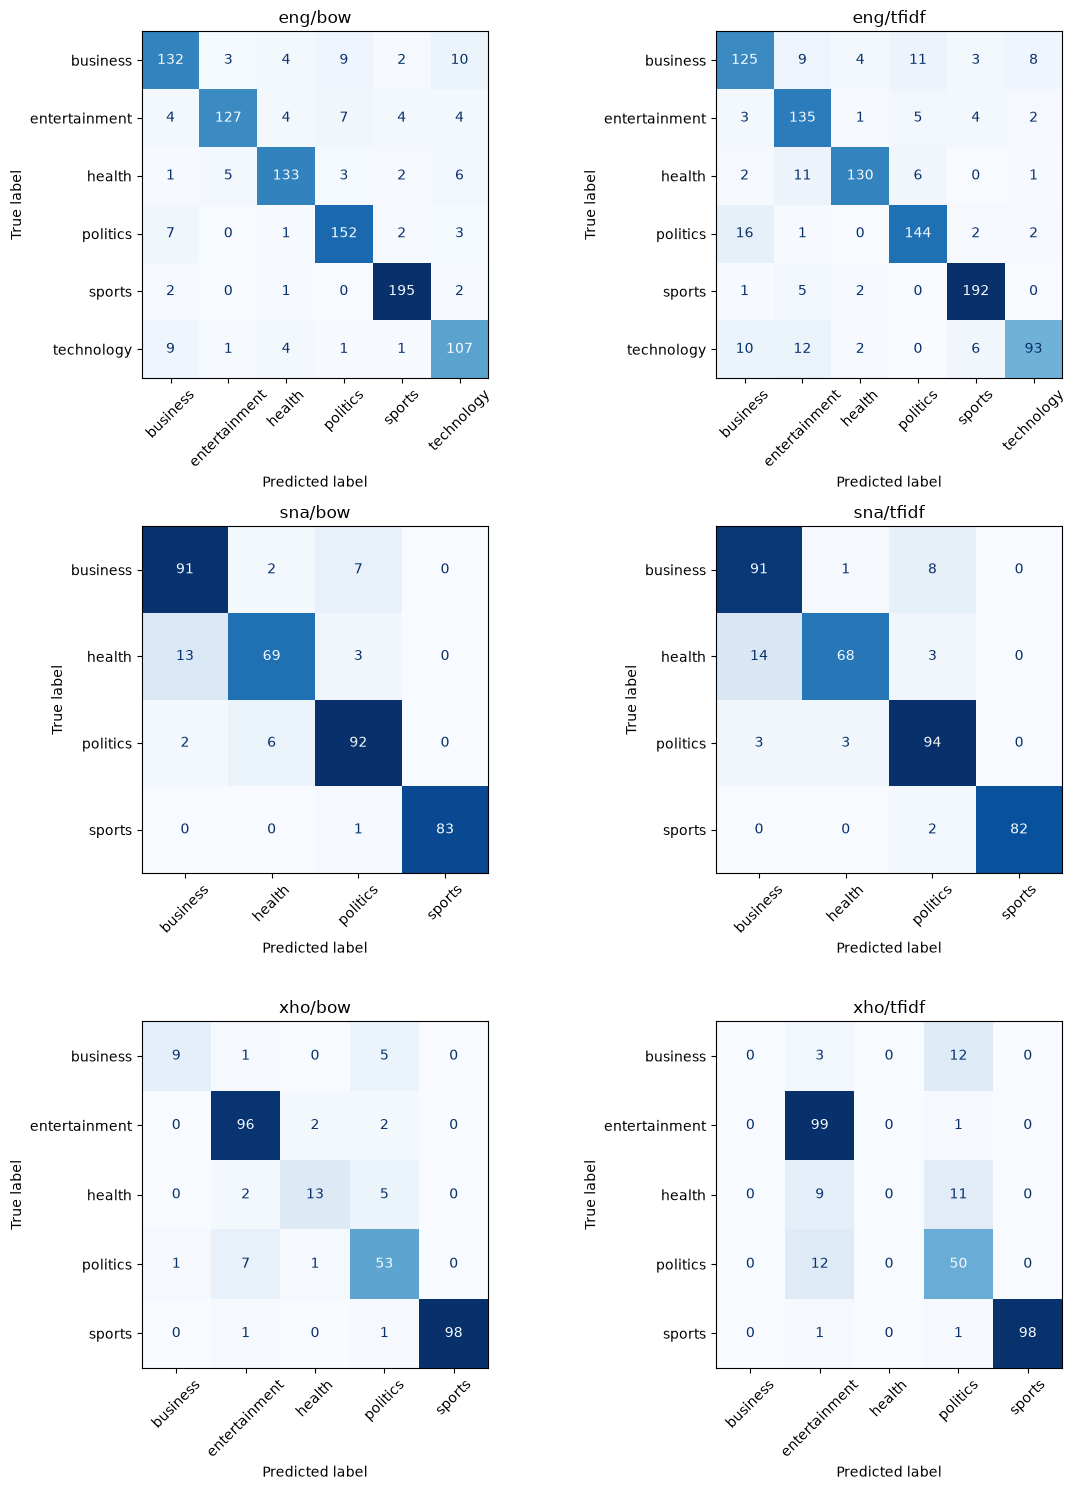

In [12]:
evaluation_rows = []
matrices = {}

for language in languages:
    for method in methods:
        results = evaluate_best(root, grid_results, language, method, device)
        matrices[(language, method)] = (results["confusion_matrix"], results["label_names"])

        evaluation_rows.append({
            "language": language,
            "method": method,
            "accuracy": results["test_accuracy"],
            "precision_micro": results["precision_micro"],
            "recall_micro": results["recall_micro"],
            "f1_micro": results["f1_micro"],
            "precision_macro": results["precision_macro"],
            "recall_macro": results["recall_macro"],
            "f1_macro": results["f1_macro"],
        })

        print(f"---- {language}/{method} (test set) ----")
        print(results["classification_report"])

summary = pd.DataFrame(evaluation_rows)
summary.to_csv("test_evaluation_summary.csv", index=False)
summary

fig, axes = plt.subplots(len(languages), len(methods), figsize=(6 * len(methods), 5 * len(languages)))

for row, language in enumerate(languages):
    for col, method in enumerate(methods):
        cm, label_names = matrices[(language, method)]
        ax = axes[row, col]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
        disp.plot(ax=ax, colorbar=False, xticks_rotation=45, cmap="Blues")
        ax.set_title(f"{language}/{method}")

plt.tight_layout()
plt.show()

Extracting softmax weights for english

In [13]:
language = "eng"

eng_results = grid_results[grid_results["language"] == language]
best_row = eng_results.loc[eng_results["accuracy"].idxmax()]
method = best_row["method"]
model = best_row["model"]

sklearn_min_df = 1 if best_row["min_df"] == 0 else int(best_row["min_df"])
max_features = None if pd.isna(best_row["max_features"]) else int(best_row["max_features"])
data = build_tensor_dataset(root, language, method, max_features=max_features, min_df=sklearn_min_df)

weights = model.linear.weight.detach().cpu().numpy()
feature_names = data["extractor"].feature_names()
label_names = data["loader"].labels

top_n = 15

for class_idx, class_name in enumerate(label_names):
    class_weights = weights[class_idx]
    top_pos_idx = np.argsort(class_weights)[-top_n:][::-1]
    top_neg_idx = np.argsort(class_weights)[:top_n]
    print(f"\n--- {class_name} ---")
    print(f"Top {top_n} words pushing towards '{class_name}'")
    for i in top_pos_idx:
        print(f"    {feature_names[i]:<20s} {class_weights[i]:+.4f}")

    print(f"\nTop {top_n} words pushing away from '{class_name}'")
    for i in top_neg_idx:
        print(f" {feature_names[i]:<20s} {class_weights[i]:+.4f}")


--- business ---
Top 15 words pushing towards 'business'
    business             +1.1830
    prices               +1.0302
    bank                 +0.8622
    workers              +0.7866
    price                +0.7314
    businesses           +0.6978
    energy               +0.6818
    oil                  +0.6007
    company              +0.5373
    economy              +0.5334
    markets              +0.5218
    bills                +0.5096
    rates                +0.5080
    its                  +0.4863
    rising               +0.4840

Top 15 words pushing away from 'business'
 health               -0.7118
 sunak                -0.5857
 ms                   -0.5351
 nhs                  -0.5264
 hospital             -0.5201
 patients             -0.5115
 ireland              -0.5111
 government           -0.4783
 care                 -0.4759
 solar                -0.4316
 were                 -0.4225
 can                  -0.4216
 google               -0.4107
 one          

get_best_config:
- returns the highest accuracy model for a language

class_counts:
- returns the number of classes based on the labels

upsample:
- returns a WeightedRandomSampler for upsampling the data of a language 

downsample:
- returns a WeightedRandomSampler for downsampling the data of a language

imbalanceExperiment:
- runs training on a language using it's best model with a sampling method and provided rates

In [14]:
def get_best_config(grid_results, language):
    subset = grid_results[grid_results["language"] == language]
    return subset.loc[subset["accuracy"].idxmax()]

def class_counts(labels, num_classes):
    return np.bincount(labels, minlength=num_classes)

def upsample(labels, num_classes, rate=1.0, seed=25):

    counts = class_counts(labels, num_classes)
    class_weights = counts.astype(np.float64) ** (-rate)
    sample_weights = class_weights[labels]

    generator = torch.Generator().manual_seed(seed)
    return WeightedRandomSampler(weights=torch.as_tensor(sample_weights, dtype=torch.double),
                                 num_samples=len(labels),
                                 replacement=True,
                                 generator=generator)

def downsample(labels, num_classes, rate=1.0, seed=25):

    counts = class_counts(labels, num_classes)
    min_count = counts.min()
    cap = int(np.ceil(min_count * rate))
    target_counts = np.minimum(counts, cap)
    sample_weights = (target_counts / counts)[labels]
    total_samples = int(target_counts.sum())

    generator = torch.Generator().manual_seed(seed)
    return WeightedRandomSampler(weights=torch.as_tensor(sample_weights, dtype=torch.double),
                                 num_samples=total_samples,
                                 replacement=False,
                                 generator=generator)

def imbalance_experiment(root, language, best_row, sampling, rates, device, num_epochs=50, patience=5, seed=42):

    method = best_row["method"]
    learning_rate = best_row["learning_rate"]
    batch_size = int(best_row["batch_size"])
    max_features = None if pd.isna(best_row["max_features"]) else int(best_row["max_features"])
    sklearn_min_df = 1 if best_row["min_df"] == 0 else int(best_row["min_df"])

    results = []

    for rate in rates:
        torch.manual_seed(seed)
        np.random.seed(seed)

        data = build_tensor_dataset(root, language, method, max_features=max_features, min_df=sklearn_min_df)
        labels = data["train"].tensors[1].numpy()

        if sampling == "upsample":
            sampler = upsample(labels, data["classes"], rate=rate, seed=seed)
        else:
            sampler = downsample(labels, data["classes"], rate=rate, seed=seed)

        model = MultinomialLogisticRegression(data["size"], data["classes"])
        history = train_model(model, data["train"], data["val"], device, learning_rate=learning_rate, batch_size=batch_size, num_epochs=num_epochs, patience=patience, sampler=sampler)

        final_epoch = len(history.val_accuracy) - 1
        results.append({
            "language": language, "method": method, "sampling": sampling, "rate": rate, "learning_rate": learning_rate, "batch_size": batch_size,
            "max_features": max_features, "min_df": sklearn_min_df, "total_epochs": len(history.val_accuracy), 
            "accuracy": history.val_accuracy[final_epoch], "loss": history.val_loss[final_epoch], "model": model, "history": history,
        })

        print(f"[{sampling}]\nrate={rate}: val_acc={results[-1]["accuracy"]:.4f}, val_loss={results[-1]["loss"]:.4f}")

    return pd.DataFrame(results)


Runs the imbalance expeeriment for both sampling methods and a vaariety of rates

Epoch [1/50]
train_loss=0.5567, val_loss=0.4656, val_acc=0.8571

Epoch [2/50]
train_loss=0.2777, val_loss=0.4075, val_acc=0.8639

Epoch [3/50]
train_loss=0.1650, val_loss=0.3839, val_acc=0.8707

Epoch [4/50]
train_loss=0.1206, val_loss=0.3638, val_acc=0.8776

Epoch [5/50]
train_loss=0.1089, val_loss=0.3370, val_acc=0.8912

Epoch [6/50]
train_loss=0.0908, val_loss=0.3344, val_acc=0.8776

Epoch [7/50]
train_loss=0.0707, val_loss=0.3268, val_acc=0.8776

Epoch [8/50]
train_loss=0.0610, val_loss=0.3169, val_acc=0.8912

Epoch [9/50]
train_loss=0.0569, val_loss=0.3193, val_acc=0.8844

Epoch [10/50]
train_loss=0.0568, val_loss=0.3064, val_acc=0.8980

Epoch [11/50]
train_loss=0.0421, val_loss=0.3049, val_acc=0.8980

Epoch [12/50]
train_loss=0.0411, val_loss=0.3115, val_acc=0.9048

Epoch [13/50]
train_loss=0.0370, val_loss=0.3034, val_acc=0.9048

Epoch [14/50]
train_loss=0.0310, val_loss=0.3055, val_acc=0.8980

Epoch [15/50]
train_loss=0.0272, val_loss=0.3120, val_acc=0.8980

Epoch [16/50]
train

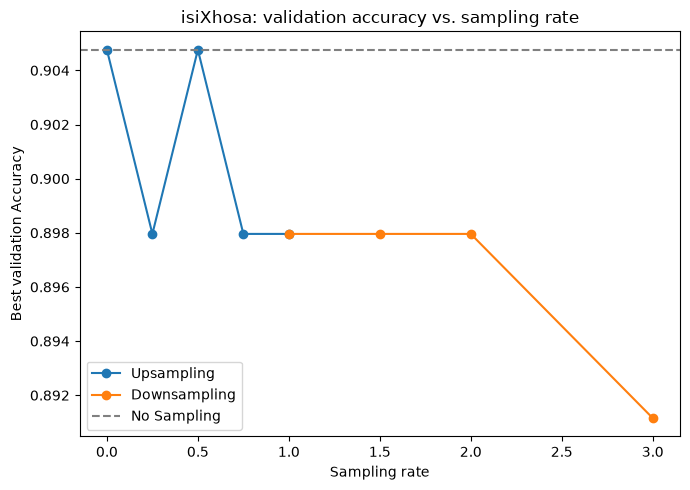

       Sampling  rate  val_accuracy  test_accuracy  test_f1_micro  \
0   No Sampling  None      0.904762       0.905724       0.905724   
1    UpSampling  None      0.904762       0.895623       0.895623   
2  Downsampling  None      0.897959       0.902357       0.902357   

   test_f1_macro  
0       0.837556  
1       0.808465  
2       0.851330  

               precision    recall  f1-score   support

     business       0.90      0.60      0.72        15
entertainment       0.90      0.96      0.93       100
       health       0.81      0.65      0.72        20
     politics       0.80      0.85      0.83        62
       sports       1.00      0.98      0.99       100

     accuracy                           0.91       297
    macro avg       0.88      0.81      0.84       297
 weighted avg       0.91      0.91      0.90       297


               precision    recall  f1-score   support

     business       0.89      0.53      0.67        15
entertainment       0.88      0.96  

In [15]:
best_xho_row = get_best_config(grid_results, "xho")
best_xho_method = best_xho_row["method"]

upsample_rates = [0.0, 0.25, 0.5, 0.75, 1.0]
downsample_rates = [1.0, 1.5, 2.0, 3.0]

upsample_results = imbalance_experiment(root, "xho", best_xho_row, "upsample", upsample_rates, device)
downsample_results = imbalance_experiment(root, "xho", best_xho_row, "downsample", downsample_rates, device)


fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(upsample_results["rate"], upsample_results["accuracy"], marker="o", label="Upsampling")
ax.plot(downsample_results["rate"], downsample_results["accuracy"], marker="o", label="Downsampling")
ax.axhline(best_xho_row["accuracy"], color="grey", linestyle="--", label="No Sampling")
ax.set_xlabel("Sampling rate")
ax.set_ylabel("Best validation Accuracy")
ax.set_title("isiXhosa: validation accuracy vs. sampling rate")
ax.legend()
plt.tight_layout()
plt.show()


baseline_test = evaluate_best(root, grid_results, "xho", best_xho_method, device)
upsample_test = evaluate_best(root, upsample_results, "xho", best_xho_method, device)
downsample_test = evaluate_best(root, downsample_results, "xho", best_xho_method, device)

comparison = pd.DataFrame([
    {"Sampling": "No Sampling", "rate": None,
     "val_accuracy": baseline_test["best_row"]["accuracy"], "test_accuracy": baseline_test["test_accuracy"],
     "test_f1_micro": baseline_test["f1_micro"], "test_f1_macro": baseline_test["f1_macro"]},
    {"Sampling": "UpSampling", "rate": None,
     "val_accuracy": upsample_test["best_row"]["accuracy"], "test_accuracy": upsample_test["test_accuracy"],
     "test_f1_micro": upsample_test["f1_micro"], "test_f1_macro": upsample_test["f1_macro"]},
    {"Sampling": "Downsampling", "rate": None,
     "val_accuracy": downsample_test["best_row"]["accuracy"], "test_accuracy": downsample_test["test_accuracy"],
     "test_f1_micro": downsample_test["f1_micro"], "test_f1_macro": downsample_test["f1_macro"]},
])

print(comparison)
print()
print(baseline_test["classification_report"])
print()
print(upsample_test["classification_report"])
print()
print(downsample_test["classification_report"])

Method for creating a combined language dataset for some lang_a and lang_b to use in bilingual training returns the name of the directory

In [16]:
def bilingual_setup(root, lang_a, lang_b, target):

    columns = ["headline", "text", "category"]

    def read_raw(lang, split):
        path = os.path.join(root, lang, f"{split}.tsv")
        return pd.read_csv(path, sep="\t", engine="python")[columns]

    labels = sorted(set(NewsDataLoader(root, lang_a).labels) | set(NewsDataLoader(root, lang_b).labels))

    name = f"{lang_a}+{lang_b}"
    dir = os.path.join(root, name)
    os.makedirs(dir, exist_ok=True)

    with open(os.path.join(dir, "labels.txt"), "w", encoding="utf-8") as f:
        f.write("\n".join(labels) + "\n")

    train = pd.concat([read_raw(lang_a, "train"), read_raw(lang_b, "train")], ignore_index=True)
    val = pd.concat([read_raw(lang_a, "dev"), read_raw(lang_b, "dev")], ignore_index=True)
    test = read_raw(target, "test")

    train.to_csv(os.path.join(dir, "train.tsv"), sep="\t", index=False)
    val.to_csv(os.path.join(dir, "dev.tsv"), sep="\t", index=False)
    test.to_csv(os.path.join(dir, "test.tsv"), sep="\t", index=False)

    return name

Running Bilingual Experiment for a variety of vocab sizes and both sna and xho and xho and eng language combinations

Epoch [1/50]
train_loss=0.6621, val_loss=0.5559, val_acc=0.8193

Epoch [2/50]
train_loss=0.3874, val_loss=0.4478, val_acc=0.8434

Epoch [3/50]
train_loss=0.3073, val_loss=0.4384, val_acc=0.8343

Epoch [4/50]
train_loss=0.2613, val_loss=0.4088, val_acc=0.8464

Epoch [5/50]
train_loss=0.2199, val_loss=0.4110, val_acc=0.8434

Epoch [6/50]
train_loss=0.2016, val_loss=0.4092, val_acc=0.8404

Epoch [7/50]
train_loss=0.1831, val_loss=0.4172, val_acc=0.8434

Epoch [8/50]
train_loss=0.1627, val_loss=0.4335, val_acc=0.8373

Epoch [9/50]
train_loss=0.1491, val_loss=0.4282, val_acc=0.8404


[xho+sna/bow] combo 1/5:
lr=0.1, batch=16, max_features=1000, min_df=3
val_acc=0.8404, val_loss=0.4282


Epoch [1/50]
train_loss=0.6149, val_loss=0.5737, val_acc=0.7982

Epoch [2/50]
train_loss=0.3207, val_loss=0.3996, val_acc=0.8735

Epoch [3/50]
train_loss=0.2242, val_loss=0.3757, val_acc=0.8705

Epoch [4/50]
train_loss=0.1729, val_loss=0.3759, val_acc=0.8705

Epoch [5/50]
train_loss=0.1412, val_loss=0.3672, 

Epoch [9/50]
train_loss=0.0800, val_loss=0.3756, val_acc=0.8614

Epoch [10/50]
train_loss=0.0726, val_loss=0.3719, val_acc=0.8614

Epoch [11/50]
train_loss=0.0663, val_loss=0.3763, val_acc=0.8675


[xho+sna/bow] combo 2/5:
lr=0.1, batch=16, max_features=2000, min_df=3
val_acc=0.8675, val_loss=0.3763


Epoch [1/50]
train_loss=0.5913, val_loss=0.4198, val_acc=0.8705

Epoch [2/50]
train_loss=0.2455, val_loss=0.3565, val_acc=0.8765

Epoch [3/50]
train_loss=0.1607, val_loss=0.3487, val_acc=0.8825

Epoch [4/50]
train_loss=0.1140, val_loss=0.3538, val_acc=0.8825

Epoch [5/50]
train_loss=0.0886, val_loss=0.3252, val_acc=0.8855

Epoch [6/50]
train_loss=0.0726, val_loss=0.3225, val_acc=0.8855

Epoch [7/50]
train_loss=0.0615, val_loss=0.3188, val_acc=0.8886

Epoch [8/50]
train_loss=0.0537, val_loss=0.3217, val_acc=0.8886

Epoch [9/50]
train_loss=0.0474, val_loss=0.3203, val_acc=0.8825

Epoch [10/50]
train_loss=0.0427, val_loss=0.3213, val_acc=0.8825

Epoch [11/50]
train_loss=0.0390, val_loss=0.32

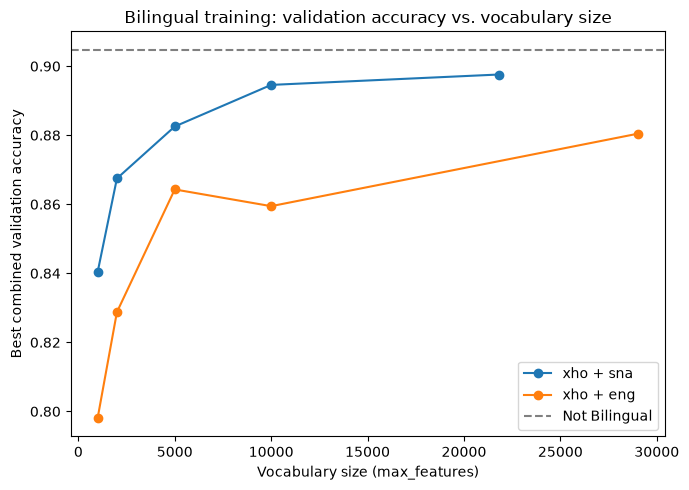


               precision    recall  f1-score   support

     business       0.89      0.53      0.67        15
entertainment       0.86      0.95      0.90       100
       health       0.90      0.45      0.60        20
     politics       0.80      0.89      0.84        62
       sports       0.99      0.98      0.98       100

     accuracy                           0.89       297
    macro avg       0.89      0.76      0.80       297
 weighted avg       0.90      0.89      0.89       297


               precision    recall  f1-score   support

     business       0.88      0.82      0.85       160
entertainment       0.92      0.87      0.89       150
       health       0.89      0.89      0.89       150
     politics       0.88      0.93      0.91       165
       sports       0.95      0.96      0.96       200
   technology       0.82      0.86      0.84       123

     accuracy                           0.89       948
    macro avg       0.89      0.89      0.89       948
 we

In [17]:
vocab_sizes = [1000, 2000, 5000, 10000, None]

method = best_xho_method
sklearn_min_df = 1 if best_xho_row["min_df"] == 0 else int(best_xho_row["min_df"])
bilingual_params = {
    "learning_rate": [best_xho_row["learning_rate"]],
    "batch_size": [int(best_xho_row["batch_size"])],
    "max_features": vocab_sizes,
    "min_df": [sklearn_min_df],
}

xho_sna_lang = bilingual_setup(root, "xho", "sna", target="xho")
xho_sna_results = tune_hyperparameters(root, xho_sna_lang, method, bilingual_params, device, num_epochs=50, patience=5)

xho_eng_lang = bilingual_setup(root, "xho", "eng", target="eng")
xho_eng_results = tune_hyperparameters(root, xho_eng_lang, method, bilingual_params, device, num_epochs=50, patience=5)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xho_sna_results["vocab_size"], xho_sna_results["accuracy"], marker="o", label="xho + sna")
ax.plot(xho_eng_results["vocab_size"], xho_eng_results["accuracy"], marker="o", label="xho + eng")
ax.axhline(best_xho_row["accuracy"], color="grey", linestyle="--", label="Not Bilingual")
ax.set_xlabel("Vocabulary size (max_features)")
ax.set_ylabel("Best combined validation accuracy")
ax.set_title("Bilingual training: validation accuracy vs. vocabulary size")
ax.legend()
plt.tight_layout()
plt.show()

bilingual_sna_test = evaluate_best(root, xho_sna_results, xho_sna_lang, method, device)
bilingual_eng_test = evaluate_best(root, xho_eng_results, xho_eng_lang, method, device)

print()
print(bilingual_sna_test["classification_report"])
print()
print(bilingual_eng_test["classification_report"])
print()

full_comparison = pd.DataFrame([
    {"Sampling": "xho + sna",
     "val_accuracy": bilingual_sna_test["best_row"]["accuracy"], "test_accuracy": bilingual_sna_test["test_accuracy"],
     "test_f1_micro": bilingual_sna_test["f1_micro"], "test_f1_macro": bilingual_sna_test["f1_macro"]},
    {"Sampling": "xho + eng",
     "val_accuracy": bilingual_eng_test["best_row"]["accuracy"], "test_accuracy": bilingual_eng_test["test_accuracy"],
     "test_f1_micro": bilingual_eng_test["f1_micro"], "test_f1_macro": bilingual_eng_test["f1_macro"]},
])

print(full_comparison)